# Fine-Tuning Médical Français — QLoRA avec Unsloth

**Modèle :** `unsloth/Llama-3.2-3B-Instruct`  
**Méthode :** QLoRA (4-bit) via Unsloth  
**Dataset :** `data/qa_finetuning.jsonl` 

##  Installation

In [1]:
# Installation Unsloth + dépendances
!pip install unsloth -q
!pip install --upgrade --no-cache-dir unsloth unsloth_zoo -q
!pip install trl datasets transformers peft accelerate bitsandbytes -q
!pip install rouge-score nltk -q

import torch
print(f'GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU seulement"}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB' if torch.cuda.is_available() else '')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.4/418.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/2

##  Configuration

In [ ]:
import os
import json
import torch
from pathlib import Path

# ============================================================
# CONFIGURATION — Modifier selon vos besoins
# ============================================================

# Modèle de base 
NOM_MODELE_BASE = "unsloth/Llama-3.2-3B-Instruct"

# Nom du modèle fine-tuné (pour sauvegarde)
NOM_MODELE_FINETUNED = "llama3-medical-french"

# Fichier dataset
FICHIER_DATASET = "qa_finetuning.jsonl"

# Hyperparamètres LoRA
LORA_R = 16              # Rang LoRA 
LORA_ALPHA = 32          # Alpha = 2 × r 
LORA_DROPOUT = 0.05      # Dropout pour régularisation

# Hyperparamètres d'entraînement
BATCH_SIZE = 2           # Par device
GRAD_ACCUMULATION = 4    # Batch effectif = 2 × 4 = 8
EPOCHS = 3               # Nombre d'époques
LEARNING_RATE = 2e-4     # Taux d'apprentissage
MAX_SEQ_LENGTH = 512     # Longueur max des séquences

# Dossier de sortie
DOSSIER_SORTIE = f"./outputs/{NOM_MODELE_FINETUNED}"
os.makedirs(DOSSIER_SORTIE, exist_ok=True)

print(f'Modèle de base      : {NOM_MODELE_BASE}')
print(f'Modèle fine-tuné    : {NOM_MODELE_FINETUNED}')
print(f'Dataset             : {FICHIER_DATASET}')
print(f'LoRA r={LORA_R}, alpha={LORA_ALPHA}')
print(f'Batch effectif      : {BATCH_SIZE * GRAD_ACCUMULATION}')

Modèle de base      : unsloth/Llama-3.2-3B-Instruct
Modèle fine-tuné    : llama3-medical-french
Dataset             : qa_finetuning.jsonl
LoRA r=16, alpha=32
Batch effectif      : 8


## Chargement du Modèle avec Unsloth

In [3]:
from unsloth import FastLanguageModel

print(f'Chargement de {NOM_MODELE_BASE} en 4-bit...')

# Chargement du modèle de base avec quantification 4-bit
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=NOM_MODELE_BASE,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,           # Auto-détection (float16 sur T4, bfloat16 sur A100)
    load_in_4bit=True,    # QLoRA : quantification 4-bit
)

print(f'✓ Modèle chargé')
print(f'Paramètres totaux : {sum(p.numel() for p in model.parameters()):,}')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Chargement de unsloth/Llama-3.2-3B-Instruct en 4-bit...
==((====))==  Unsloth 2026.4.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


✓ Modèle chargé
Paramètres totaux : 1,841,212,416


## Configuration des Adaptateurs LoRA

In [4]:
# Ajout des adaptateurs LoRA au modèle
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",  # Économise 30% VRAM
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)

# Afficher les paramètres entraînables
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Paramètres entraînables : {trainable:,} ({100*trainable/total:.2f}%)')
print(f'Paramètres gelés        : {total - trainable:,}')

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.4 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Paramètres entraînables : 24,313,856 (1.30%)
Paramètres gelés        : 1,841,212,416


## Préparation du Dataset

In [ ]:
from datasets import Dataset

print(f'Chargement du dataset : {FICHIER_DATASET}')
data = []
with open(FICHIER_DATASET, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            data.append(json.loads(line))

print(f'Exemples chargés : {len(data)}')
print(f'\nExemple du dataset :')
print(json.dumps(data[0], ensure_ascii=False, indent=2)[:400])

Chargement du dataset : qa_finetuning.jsonl
Exemples chargés : 1513

Exemple du dataset :
{
  "messages": [
    {
      "role": "system",
      "content": "Tu es un assistant médical expert en français. Réponds aux questions médicales de manière précise, claire et structurée, basée sur des données médicales fiables."
    },
    {
      "role": "user",
      "content": "Quelle est la licence sous laquelle le manuel technique de l'OMS sur la politique et l'administration des taxes prélev


In [ ]:
# Template de chat pour Llama 3.2
def formater_exemple(exemple):
    """
    Formate un exemple au format chat template de Llama 3.2.
    Utilise le tokenizer pour appliquer le bon template.
    """
    messages = exemple.get('messages', [])

    # Extraire system, user, assistant
    system = next((m['content'] for m in messages if m['role'] == 'system'),
                  "Tu es un assistant médical expert en français.")
    user = next((m['content'] for m in messages if m['role'] == 'user'), '')
    assistant = next((m['content'] for m in messages if m['role'] == 'assistant'), '')

    # Appliquer le chat template
    chat = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
        {"role": "assistant", "content": assistant}
    ]

    texte = tokenizer.apply_chat_template(
        chat,
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": texte}

# Convertir en Dataset HuggingFace
dataset_hf = Dataset.from_list(data)
dataset_formate = dataset_hf.map(formater_exemple, remove_columns=dataset_hf.column_names)

# Split train/validation 90/10
split = dataset_formate.train_test_split(test_size=0.1, seed=42)
train_dataset = split['train']
eval_dataset = split['test']

print(f'  Dataset préparé :')
print(f'  Train      : {len(train_dataset)} exemples')
print(f'  Validation : {len(eval_dataset)} exemples')
print(f'Exemple formaté (200 premiers caractères) :')
print(train_dataset[0]['text'][:500])

Map:   0%|          | 0/1513 [00:00<?, ? examples/s]


Dataset préparé :
  Train      : 1361 exemples
  Validation : 152 exemples

Exemple formaté (200 premiers caractères) :
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 12 Apr 2026

Tu es un assistant médical expert en français. Réponds aux questions médicales de manière précise, claire et structurée, basée sur des données médicales fiables.<|eot_id|><|start_header_id|>user<|end_header_id|>

Quelle est la licence sous laquelle le texte médical est publié ?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Le texte médical est publié sous une lice


## Configuration de l'Entraînement

In [8]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

# Vérifier si bfloat16 est supporté (A100/H100) ou utiliser float16 (T4)
dtype_precision = torch.bfloat16 if is_bfloat16_supported() else torch.float16
print(f'Précision utilisée : {"bfloat16" if is_bfloat16_supported() else "float16"}')

# Arguments d'entraînement
training_args = TrainingArguments(
    output_dir=DOSSIER_SORTIE,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUMULATION,
    warmup_steps=10,
    learning_rate=LEARNING_RATE,
    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),
    logging_steps=10,
    optim="adamw_8bit",            # Optimiseur 8-bit économise VRAM
    weight_decay=0.01,
    lr_scheduler_type="cosine",    # Décroissance cosinus
    seed=42,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",              # Désactiver wandb
)

# Trainer SFT (Supervised Fine-Tuning)
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    args=training_args,
)

print('✓ Trainer configuré')
print(f'Étapes totales : {len(train_dataset) // (BATCH_SIZE * GRAD_ACCUMULATION) * EPOCHS}')

Précision utilisée : float16


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1361 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/152 [00:00<?, ? examples/s]

✓ Trainer configuré
Étapes totales : 510


## Entraînement

In [ ]:
# Afficher la mémoire GPU avant entraînement
if torch.cuda.is_available():
    gpu_stats = torch.cuda.get_device_properties(0)
    vram_libre = round(torch.cuda.mem_get_info()[0] / 1024**3, 1)
    vram_totale = round(gpu_stats.total_memory / 1024**3, 1)
    print(f'VRAM : {vram_libre}/{vram_totale} GB disponibles')

print('\nDébut de l\'entraînement...')
print('=' * 50)

# Lancement de l'entraînement
resultats = trainer.train()

print('=' * 50)
print('✓ Entraînement terminé')
print(f'Loss finale     : {resultats.training_loss:.4f}')
print(f'Durée totale    : {resultats.metrics["train_runtime"]:.0f}s ({resultats.metrics["train_runtime"]/60:.1f} min)')
print(f'Vitesse         : {resultats.metrics["train_samples_per_second"]:.1f} exemples/sec')

VRAM : 12.1/14.6 GB disponibles

Début de l'entraînement...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,361 | Num Epochs = 3 | Total steps = 513
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.528215,0.499062
2,0.363382,0.450132
3,0.272779,0.465677


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


✓ Entraînement terminé
Loss finale     : 0.4602
Durée totale    : 1042s (17.4 min)
Vitesse         : 3.9 exemples/sec


## Sauvegarde du Modèle

In [ ]:
# Sauvegarde des adaptateurs LoRA (petit fichier ~100MB)
chemin_lora = f"{DOSSIER_SORTIE}/lora_adapters"
model.save_pretrained(chemin_lora)
tokenizer.save_pretrained(chemin_lora)
print(f'✓ Adaptateurs LoRA sauvegardés : {chemin_lora}')


#Pousser sur HuggingFace Hub
# HF_TOKEN = "hf_votre_token"
# model.push_to_hub(f"votre_username/{NOM_MODELE_FINETUNED}", token=HF_TOKEN)
# tokenizer.push_to_hub(f"votre_username/{NOM_MODELE_FINETUNED}", token=HF_TOKEN)

print('\nFichiers sauvegardés :')
import os
for f in os.listdir(chemin_lora):
    taille = os.path.getsize(os.path.join(chemin_lora, f)) / 1e6
    print(f'  {f} ({taille:.1f} MB)')

✓ Adaptateurs LoRA sauvegardés : ./outputs/llama3-medical-french/lora_adapters

Fichiers sauvegardés :
  adapter_model.safetensors (97.3 MB)
  chat_template.jinja (0.0 MB)
  tokenizer.json (17.2 MB)
  adapter_config.json (0.0 MB)
  README.md (0.0 MB)
  tokenizer_config.json (0.0 MB)


##  Inférence : Test du Modèle Fine-Tuné

In [13]:
from unsloth import FastLanguageModel

# Activer le mode inférence (2x plus rapide)
FastLanguageModel.for_inference(model)

def generer_reponse(question: str, max_tokens: int = 300) -> str:
    """
    Génère une réponse médicale avec le modèle fine-tuné.
    """
    messages = [
        {"role": "system", "content": "Tu es un assistant médical expert en français. Réponds aux questions médicales de manière précise et structurée."},
        {"role": "user", "content": question}
    ]

    # Appliquer le chat template
    texte_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # Tokeniser
    inputs = tokenizer(texte_input, return_tensors="pt").to(model.device)

    # Générer
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Décoder uniquement la réponse générée
    reponse = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    return reponse.strip()

# Questions de test médicales en français
questions_test = [
     " Quels sont les cinq éléments interdépendants qui composent les soins attentifs pour les enfants ?"
     "Pourquoi le premier mois de vie est-il considéré comme une période primordiale pour le développement de l'enfant ?",
     "Quels sont les risques pour un nouveau-né s'il est privé de soins prodigués avec amour ?",
     "Quels sont les bénéfices de l'implication des pères pendant la période prénatale ?"
]

print('=== TEST DU MODÈLE FINE-TUNÉ ===')
print('=' * 60)

for i, question in enumerate(questions_test, 1):
    print(f'\n[Question {i}] {question}')
    print('-' * 40)
    reponse = generer_reponse(question)
    print(f'Réponse : {reponse}')
    print()

Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== TEST DU MODÈLE FINE-TUNÉ ===

[Question 1]  Quels sont les cinq éléments interdépendants qui composent les soins attentifs pour les enfants ?Pourquoi le premier mois de vie est-il considéré comme une période primordiale pour le développement de l'enfant ?
----------------------------------------


Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Réponse : Les cinq éléments interdépendants qui composent les soins attentifs pour les enfants sont : une bonne santé, une nutrition adéquate, la sûreté et la sécurité, la prestation de soins adaptés et des possibilités d'apprentissage précoce. Le premier mois de vie est considéré comme une période primordiale pour le développement de l'enfant car il est essentiel pour la croissance et le développement de l'enfant, et les premières minutes et les premières heures de vie sont cruciales pour la santé et le bien-être de l'enfant.


[Question 2] Quels sont les risques pour un nouveau-né s'il est privé de soins prodigués avec amour ?
----------------------------------------


Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Réponse : Le nouveau-né peut être exposé à un risque accru de décès ou de handicap.


[Question 3] Quels sont les bénéfices de l'implication des pères pendant la période prénatale ?
----------------------------------------
Réponse : L'implication des pères pendant la période prénatale peut améliorer la santé maternelle et du nouveau-né, ainsi que la qualité parentale et le développement du nourrisson.



## Évaluation Quantitative (ROUGE-L, BLEU, F1)

In [15]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
smooth = SmoothingFunction().method1

def evaluer_modele(dataset_eval, n_exemples=30):
    """
    Évalue le modèle fine-tuné sur un subset du dataset.
    Calcule ROUGE-L, BLEU et F1-Token.
    """
    resultats = []

    # Recharger les données brutes pour avoir les Q/R originales
    data_brut = []
    with open('qa_brut.jsonl', 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data_brut.append(json.loads(line.strip()))

    # Prendre un sample aléatoire
    import random
    random.seed(42)
    sample = random.sample(data_brut, min(n_exemples, len(data_brut)))

    print(f'Évaluation sur {len(sample)} exemples...')

    for ex in sample:
        question = ex['question']
        reference = ex['answer']

        # Générer la réponse du modèle
        prediction = generer_reponse(question, max_tokens=200)

        # ROUGE-L
        rouge_l = scorer.score(reference, prediction)['rougeL'].fmeasure

        # BLEU
        ref_tokens = nltk.word_tokenize(reference.lower())
        pred_tokens = nltk.word_tokenize(prediction.lower()) if prediction else ['.']
        bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth)

        # F1-Token
        pred_set = set(prediction.lower().split())
        ref_set = set(reference.lower().split())
        commun = pred_set & ref_set
        precision = len(commun) / len(pred_set) if pred_set else 0
        rappel = len(commun) / len(ref_set) if ref_set else 0
        f1 = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

        resultats.append({
            'question': question[:80],
            'rouge_l': rouge_l,
            'bleu': bleu,
            'f1': f1
        })

    return resultats

# Lancer l'évaluation
print('Évaluation du modèle fine-tuné...')
resultats_eval = evaluer_modele(eval_dataset, n_exemples=20)

# Calculer les moyennes
rouge_moyen = sum(r['rouge_l'] for r in resultats_eval) / len(resultats_eval)
bleu_moyen = sum(r['bleu'] for r in resultats_eval) / len(resultats_eval)
f1_moyen = sum(r['f1'] for r in resultats_eval) / len(resultats_eval)

print('\n' + '=' * 50)
print('RÉSULTATS D\'ÉVALUATION — MODÈLE FINE-TUNÉ')
print('=' * 50)
print(f'ROUGE-L moyen  : {rouge_moyen:.4f}')
print(f'BLEU moyen     : {bleu_moyen:.4f}')
print(f'F1-Token moyen : {f1_moyen:.4f}')

# Sauvegarder les résultats
import pandas as pd
df_eval = pd.DataFrame(resultats_eval)
df_eval.to_csv('outputs/resultats_evaluation_finetuned.csv', index=False)
print(f'\nRésultats sauvegardés : outputs/resultats_evaluation_finetuned.csv')

Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Évaluation du modèle fine-tuné...
Évaluation sur 20 exemples...


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_


RÉSULTATS D'ÉVALUATION — MODÈLE FINE-TUNÉ
ROUGE-L moyen  : 0.5808
BLEU moyen     : 0.3872
F1-Token moyen : 0.5845

Résultats sauvegardés : outputs/resultats_evaluation_finetuned.csv


## Cellule 11 — Visualisation de la Courbe de Loss

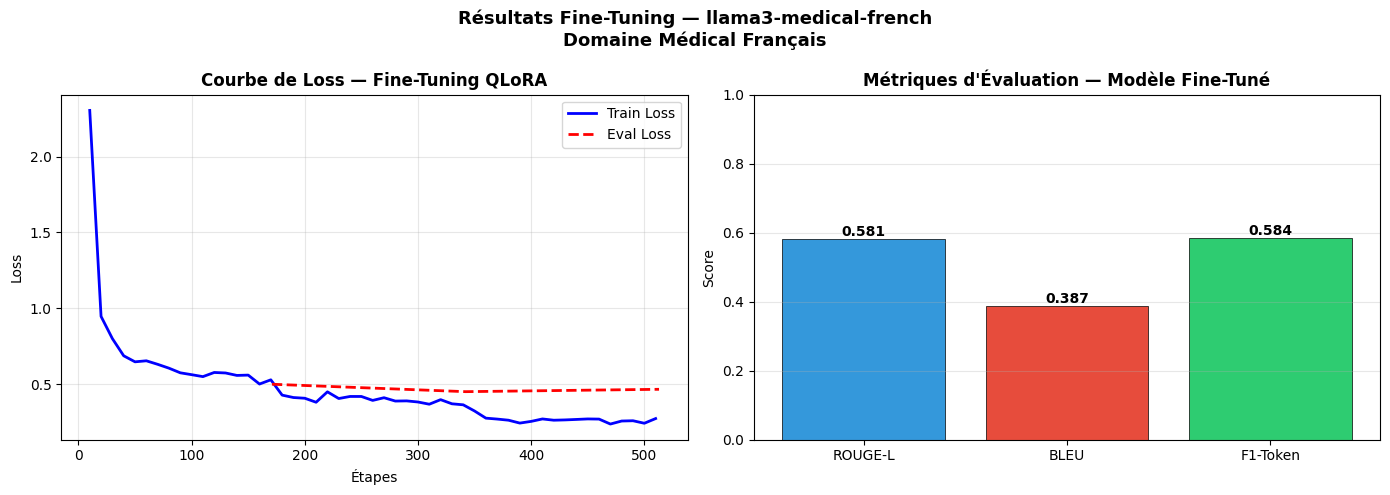

Modèle sauvegardé dans : ./outputs/llama3-medical-french/lora_adapters


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Extraire l'historique des logs
historique = trainer.state.log_history

# Séparer train et eval
train_loss = [(h['step'], h['loss']) for h in historique if 'loss' in h and 'eval_loss' not in h]
eval_loss = [(h['step'], h['eval_loss']) for h in historique if 'eval_loss' in h]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de loss
if train_loss:
    steps_train, loss_train = zip(*train_loss)
    axes[0].plot(steps_train, loss_train, 'b-', label='Train Loss', linewidth=2)
if eval_loss:
    steps_eval, loss_eval = zip(*eval_loss)
    axes[0].plot(steps_eval, loss_eval, 'r--', label='Eval Loss', linewidth=2)

axes[0].set_title('Courbe de Loss — Fine-Tuning QLoRA', fontweight='bold')
axes[0].set_xlabel('Étapes')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Métriques finales
metriques = ['ROUGE-L', 'BLEU', 'F1-Token']
valeurs = [rouge_moyen, bleu_moyen, f1_moyen]
couleurs = ['#3498db', '#e74c3c', '#2ecc71']

barres = axes[1].bar(metriques, valeurs, color=couleurs, edgecolor='black', linewidth=0.5)
axes[1].set_title('Métriques d\'Évaluation — Modèle Fine-Tuné', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

for barre, val in zip(barres, valeurs):
    axes[1].text(barre.get_x() + barre.get_width()/2., barre.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle(f'Résultats Fine-Tuning — {NOM_MODELE_FINETUNED}\nDomaine Médical Français',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/courbes_finetuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Modèle sauvegardé dans : {chemin_lora}')